In [3]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

ALU_VCF  = "/gpfs/data/user/shweta_lab/data/TE/TE_discovery/Jan_May_2026/filtered_vcfs/ALU.filtered.vcf.gz"
L1_VCF   = "/gpfs/data/user/shweta_lab/data/TE/TE_discovery/Jan_May_2026/filtered_vcfs/LINE1.filtered.vcf.gz"
MAP_FILE = "/gpfs/data/user/shweta_lab/data/TE/TE_discovery/Jan_May_2026/filtered_vcfs/sample_population_map.csv"
OUTDIR   = "/gpfs/data/user/shweta_lab/data/TE/TE_discovery/Jan_May_2026/Results/Basic_Analysis/subfamily_plots"
os.makedirs(OUTDIR, exist_ok=True)

In [4]:
%%bash
source ~/.bashrc
conda activate rnaseq_r
module load bcftools-1.21

L1_VCF=/gpfs/data/user/shweta_lab/data/TE/TE_discovery/Jan_May_2026/filtered_vcfs/LINE1.filtered.vcf.gz
ALU_VCF=/gpfs/data/user/shweta_lab/data/TE/TE_discovery/Jan_May_2026/filtered_vcfs/ALU.filtered.vcf.gz
OUTDIR=/gpfs/data/user/shweta_lab/data/TE/TE_discovery/Jan_May_2026/Results/Basic_Analysis/subfamily_plots

mkdir -p $OUTDIR

bcftools query -f '%CHROM\t%POS\t%INFO/MEINFO[\t%GT]\n' $L1_VCF > $OUTDIR/LINE1_gt_raw.tsv
bcftools query -l $L1_VCF > $OUTDIR/LINE1_samples.txt

bcftools query -f '%CHROM\t%POS\t%INFO/MEINFO[\t%GT]\n' $ALU_VCF > $OUTDIR/ALU_gt_raw.tsv
bcftools query -l $ALU_VCF > $OUTDIR/ALU_samples.txt

echo "LINE1 sites: $(wc -l < $OUTDIR/LINE1_gt_raw.tsv)"
echo "ALU sites:   $(wc -l < $OUTDIR/ALU_gt_raw.tsv)"

[W::bcf_hdr_check_sanity] GL should be declared as Number=G
[W::bcf_hdr_check_sanity] GL should be declared as Number=G
[W::bcf_hdr_check_sanity] GL should be declared as Number=G
[W::bcf_hdr_check_sanity] GL should be declared as Number=G


LINE1 sites: 7093
ALU sites:   26990


In [6]:
map_df = pd.read_csv(MAP_FILE, header=0)
map_df.columns = ["sample","pop","superpop_raw","twin_flag"] + list(map_df.columns[4:])
map_df["sample"]   = map_df["sample"].astype(str).str.split("_").str[0]
map_df["superpop"] = map_df["superpop_raw"] + "_" + map_df["twin_flag"].map({"Yes":"T","No":"NT"}).fillna("NA")
map_df = map_df[map_df["pop"].notna() & (map_df["superpop_raw"] != "")]
map_df = map_df.drop_duplicates(subset="sample")
print(f"Samples in map: {len(map_df)}")
print(map_df["superpop"].value_counts())

Samples in map: 9718
IE_NT    5440
DR_NT    1809
IE_T      713
AA_T      601
DR_T      536
TB_T      460
TB_NT     159
Name: superpop, dtype: int64


In [7]:
def build_counts(gt_file, samples_file, map_df, label):
    print(f"\nProcessing: {label}")

    vcf_samples       = pd.read_csv(samples_file, header=None)[0].tolist()
    vcf_samples_clean = [s.split("_")[0] for s in vcf_samples]
    print(f"  Samples in VCF: {len(vcf_samples)}")

    gt_df = pd.read_csv(gt_file, sep="\t", header=None, low_memory=False)
    print(f"  Sites loaded: {len(gt_df)}")

    subfamily   = gt_df.iloc[:,2].astype(str).str.split(",").str[0].values
    site_ids    = (gt_df.iloc[:,0].astype(str) + "_" + gt_df.iloc[:,1].astype(str)).values
    gt_mat      = gt_df.iloc[:,3:].values
    present_mat = np.isin(gt_mat, ["0/1","1/0","0|1","1|0","1/1","1|1"]).astype(np.int8)

    sample_info = pd.DataFrame({"idx": range(len(vcf_samples)), "sample": vcf_samples_clean})
    sample_info = sample_info.merge(map_df[["sample","pop","superpop"]], on="sample", how="inner")
    print(f"  Matched samples: {len(sample_info)}")

    any_present    = present_mat.sum(axis=1) > 0
    overall_counts = pd.Series(subfamily[any_present]).value_counts().rename_axis("subfamily").reset_index(name="N")

    pop_rows = []
    for pop_val, grp in sample_info.groupby("pop"):
        idxs = grp["idx"].values
        mask = present_mat[:, idxs].sum(axis=1) > 0
        pop_rows.append(pd.DataFrame({"group": pop_val, "subfamily": subfamily[mask]}))
    pop_counts = pd.concat(pop_rows).groupby(["group","subfamily"]).size().reset_index(name="N")

    sp_rows = []
    for sp_val, grp in sample_info.groupby("superpop"):
        idxs = grp["idx"].values
        mask = present_mat[:, idxs].sum(axis=1) > 0
        sp_rows.append(pd.DataFrame({"group": sp_val, "subfamily": subfamily[mask]}))
    sp_counts = pd.concat(sp_rows).groupby(["group","subfamily"]).size().reset_index(name="N")

    return {"overall": overall_counts, "pop": pop_counts, "superpop": sp_counts}

In [8]:
def make_plots(counts, label, outdir, top_n=20):
    overall_dt = counts["overall"]
    pop_dt     = counts["pop"]
    sp_dt      = counts["superpop"]

    top_sf  = overall_dt.nlargest(top_n, "N")["subfamily"].tolist()
    cmap    = plt.cm.get_cmap("tab20", len(top_sf))
    palette = {sf: cmap(i) for i, sf in enumerate(top_sf)}
    palette["Other"] = (0.6, 0.6, 0.6)

    def get_sf_plot(sf):
        return sf if sf in top_sf else "Other"

    # overall
    ov = overall_dt.copy()
    ov["subfamily_plot"] = ov["subfamily"].apply(get_sf_plot)
    ov = ov.groupby("subfamily_plot")["N"].sum().reset_index()
    order = [s for s in top_sf if s in ov["subfamily_plot"].values] + ["Other"]
    ov["subfamily_plot"] = pd.Categorical(ov["subfamily_plot"], categories=order, ordered=True)
    ov = ov.sort_values("subfamily_plot")

    fig, ax = plt.subplots(figsize=(max(8, top_n*0.8), 5))
    bars = ax.bar(ov["subfamily_plot"].astype(str), ov["N"],
                  color=[palette.get(s,(0.6,0.6,0.6)) for s in ov["subfamily_plot"].astype(str)])
    for bar, n in zip(bars, ov["N"]):
        ax.text(bar.get_x()+bar.get_width()/2, bar.get_height(), str(n),
                ha="center", va="bottom", fontsize=8)
    ax.set_xticklabels(ov["subfamily_plot"].astype(str), rotation=45, ha="right")
    ax.set_xlabel("Subfamily"); ax.set_ylabel("Unique insertions")
    ax.set_title(f"{label} - Unique insertions per subfamily (global)")
    ax.spines[["top","right"]].set_visible(False)
    plt.tight_layout()
    plt.savefig(f"{outdir}/{label.lower()}_overall.png", dpi=150)
    plt.show()

    def make_facet(dt, title, fname):
        dt = dt.copy()
        dt["subfamily_plot"] = dt["subfamily"].apply(get_sf_plot)
        agg = dt.groupby(["group","subfamily_plot"])["N"].sum().reset_index()
        sf_order = [s for s in top_sf if s in agg["subfamily_plot"].values] + ["Other"]
        agg["subfamily_plot"] = pd.Categorical(agg["subfamily_plot"], categories=sf_order, ordered=True)

        groups = sorted(agg["group"].unique())
        ncols  = int(np.ceil(np.sqrt(len(groups))))
        nrows  = int(np.ceil(len(groups) / ncols))

        fig, axes = plt.subplots(nrows, ncols,
                                 figsize=(min(4*ncols,28), min(4*nrows,20)))
        axes = np.array(axes).flatten()

        for i, grp in enumerate(groups):
            sub = agg[agg["group"]==grp].sort_values("subfamily_plot")
            axes[i].bar(sub["subfamily_plot"].astype(str), sub["N"],
                        color=[palette.get(s,(0.6,0.6,0.6)) for s in sub["subfamily_plot"].astype(str)])
            axes[i].set_title(grp, fontsize=8)
            axes[i].set_xticklabels(sub["subfamily_plot"].astype(str), rotation=45, ha="right", fontsize=6)
            axes[i].spines[["top","right"]].set_visible(False)

        for j in range(i+1, len(axes)):
            axes[j].set_visible(False)

        fig.suptitle(title, fontsize=10)
        plt.tight_layout()
        plt.savefig(f"{outdir}/{fname}", dpi=150)
        plt.show()
        print(f"  Saved {fname}")

    make_facet(pop_dt, f"{label} - per population",      f"{label.lower()}_per_pop.png")
    make_facet(sp_dt,  f"{label} - per superpopulation", f"{label.lower()}_per_superpop.png")


Processing: ALU
  Samples in VCF: 7478
  Sites loaded: 26990
  Matched samples: 7439


/tmp/ipykernel_352130/3405121477.py:28: UserWarning: FixedFormatter should only be used together with FixedLocator
  ax.set_xticklabels(ov["subfamily_plot"].astype(str), rotation=45, ha="right")


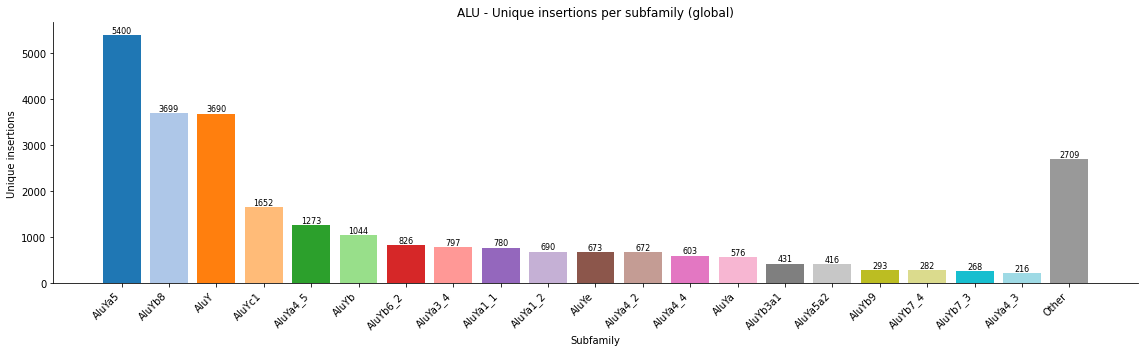

/tmp/ipykernel_352130/3405121477.py:56: UserWarning: FixedFormatter should only be used together with FixedLocator
  axes[i].set_xticklabels(sub["subfamily_plot"].astype(str), rotation=45, ha="right", fontsize=6)
/tmp/ipykernel_352130/3405121477.py:56: UserWarning: FixedFormatter should only be used together with FixedLocator
  axes[i].set_xticklabels(sub["subfamily_plot"].astype(str), rotation=45, ha="right", fontsize=6)
/tmp/ipykernel_352130/3405121477.py:56: UserWarning: FixedFormatter should only be used together with FixedLocator
  axes[i].set_xticklabels(sub["subfamily_plot"].astype(str), rotation=45, ha="right", fontsize=6)
/tmp/ipykernel_352130/3405121477.py:56: UserWarning: FixedFormatter should only be used together with FixedLocator
  axes[i].set_xticklabels(sub["subfamily_plot"].astype(str), rotation=45, ha="right", fontsize=6)
/tmp/ipykernel_352130/3405121477.py:56: UserWarning: FixedFormatter should only be used together with FixedLocator
  axes[i].set_xticklabels(sub["su

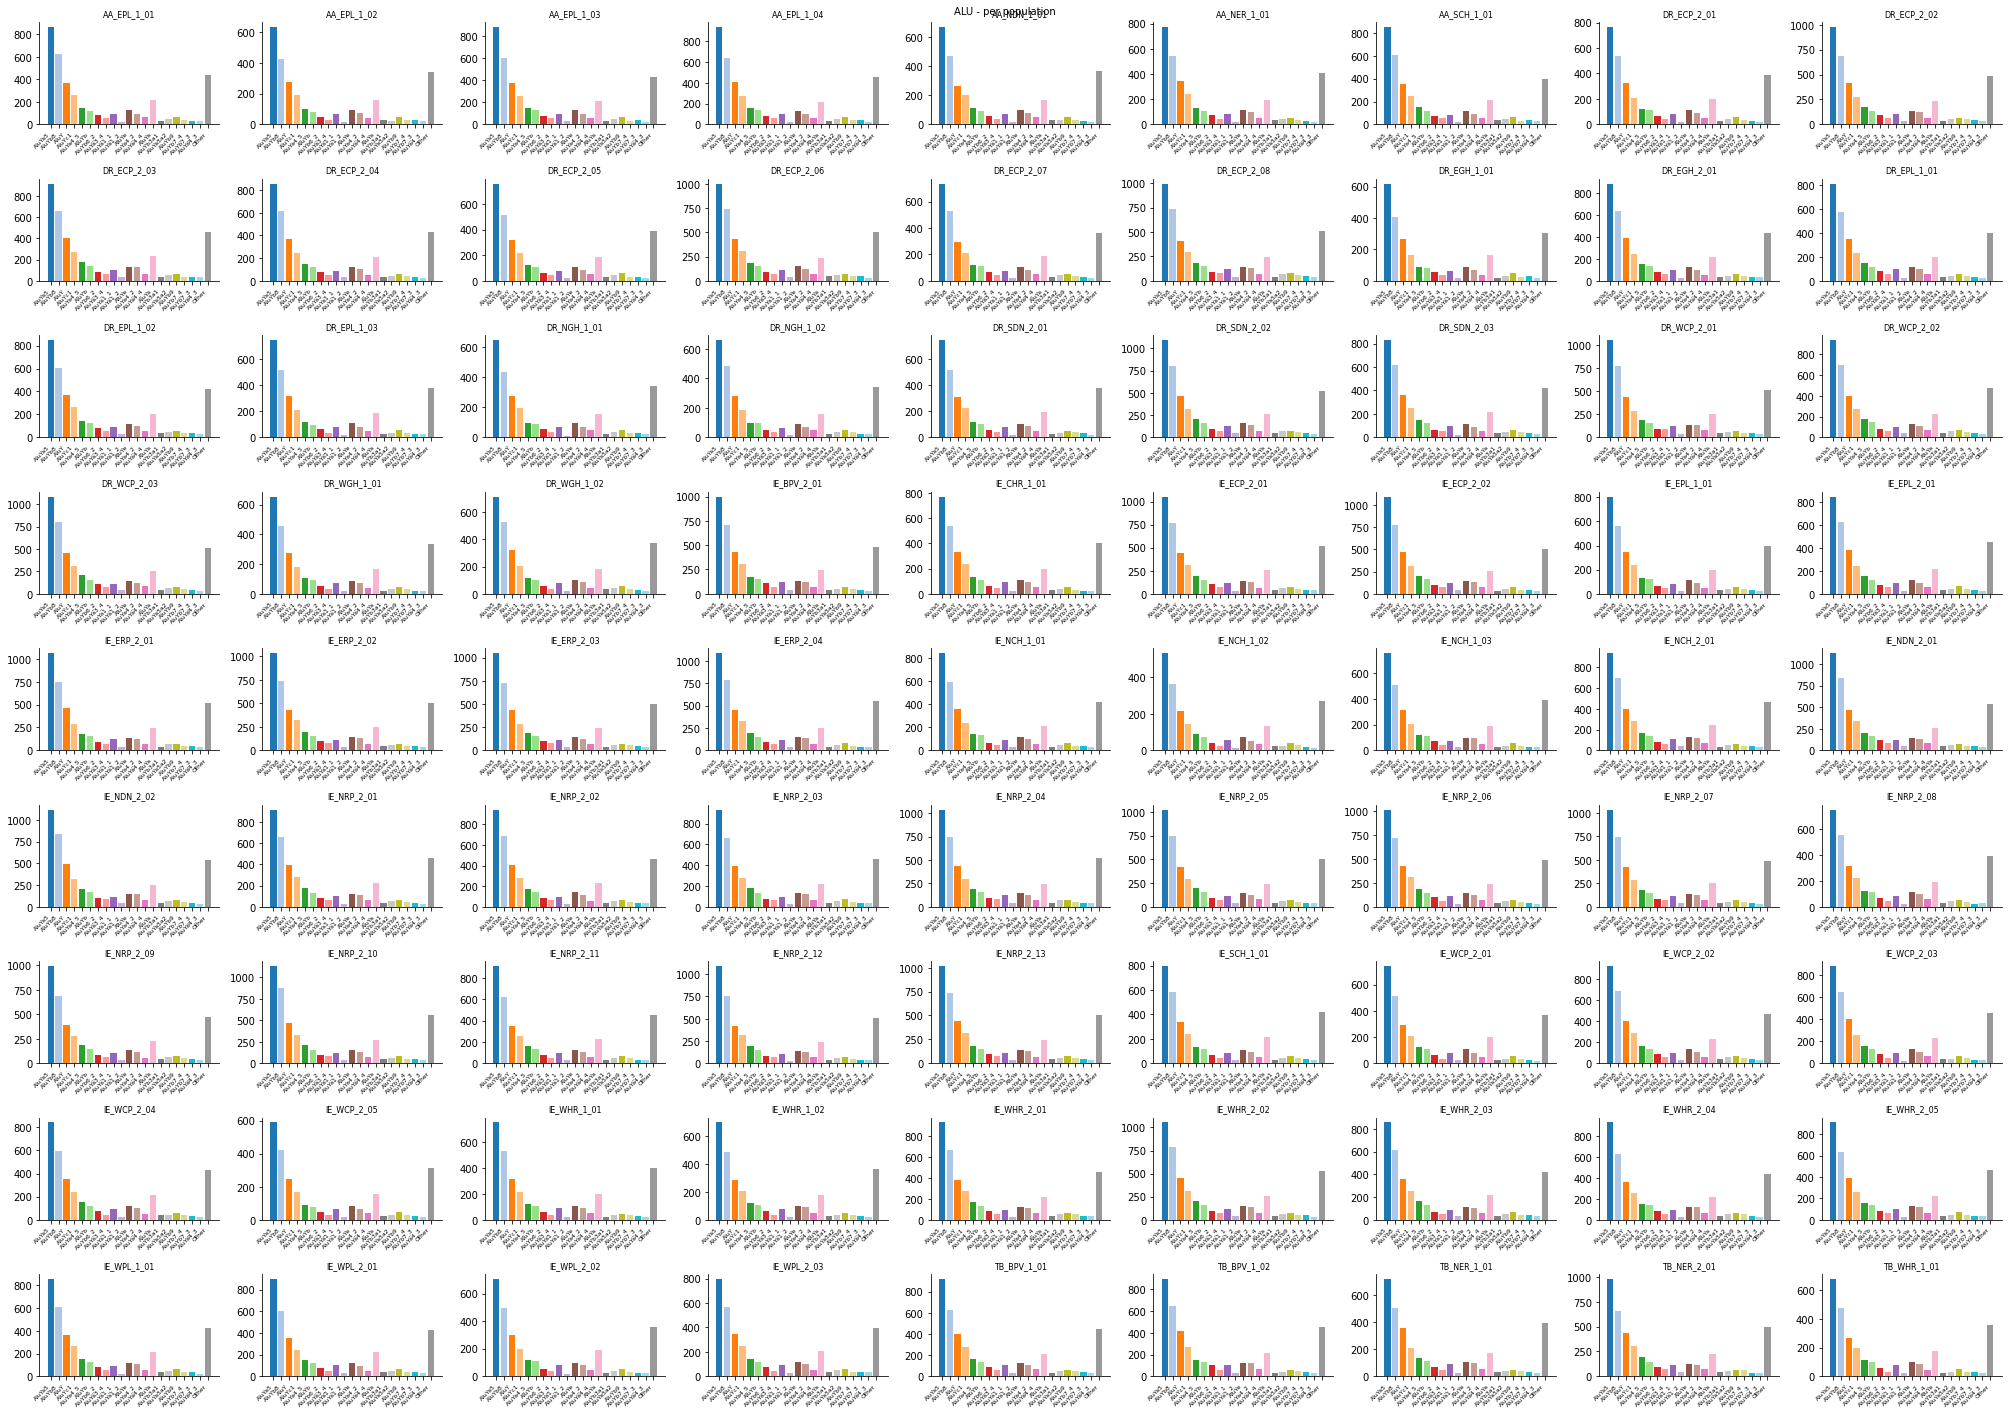

  Saved alu_per_pop.png


/tmp/ipykernel_352130/3405121477.py:56: UserWarning: FixedFormatter should only be used together with FixedLocator
  axes[i].set_xticklabels(sub["subfamily_plot"].astype(str), rotation=45, ha="right", fontsize=6)
/tmp/ipykernel_352130/3405121477.py:56: UserWarning: FixedFormatter should only be used together with FixedLocator
  axes[i].set_xticklabels(sub["subfamily_plot"].astype(str), rotation=45, ha="right", fontsize=6)
/tmp/ipykernel_352130/3405121477.py:56: UserWarning: FixedFormatter should only be used together with FixedLocator
  axes[i].set_xticklabels(sub["subfamily_plot"].astype(str), rotation=45, ha="right", fontsize=6)
/tmp/ipykernel_352130/3405121477.py:56: UserWarning: FixedFormatter should only be used together with FixedLocator
  axes[i].set_xticklabels(sub["subfamily_plot"].astype(str), rotation=45, ha="right", fontsize=6)
/tmp/ipykernel_352130/3405121477.py:56: UserWarning: FixedFormatter should only be used together with FixedLocator
  axes[i].set_xticklabels(sub["su

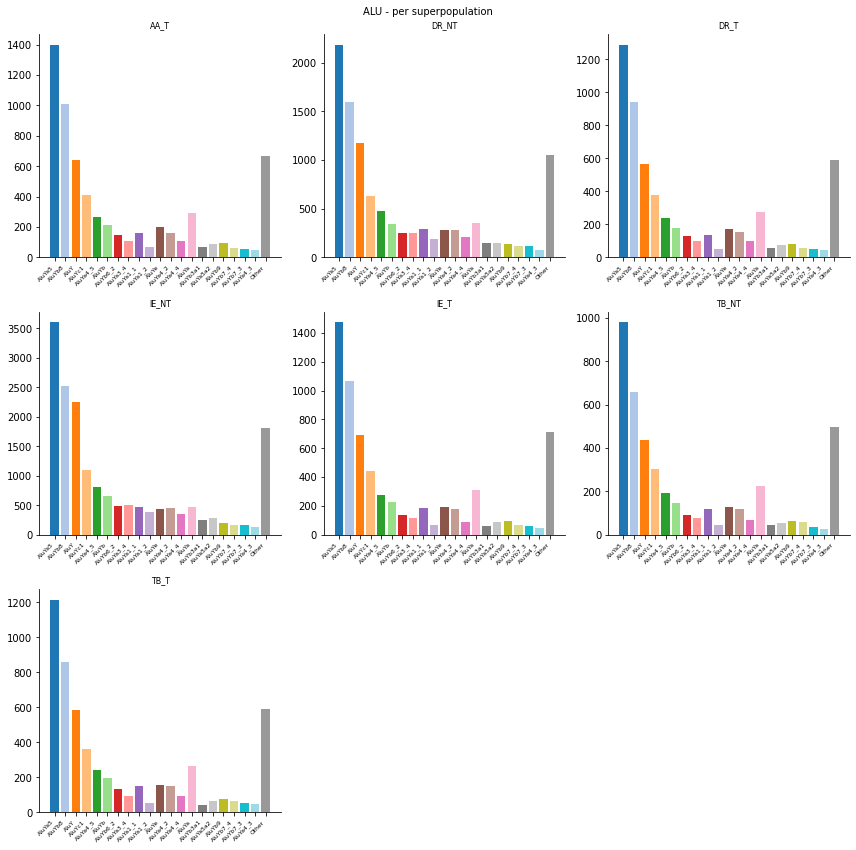

  Saved alu_per_superpop.png


In [9]:
alu_counts = build_counts(f"{OUTDIR}/ALU_gt_raw.tsv", f"{OUTDIR}/ALU_samples.txt", map_df, "ALU")
make_plots(alu_counts, "ALU", OUTDIR, top_n=20)


Processing: LINE1
  Samples in VCF: 7478
  Sites loaded: 7093
  Matched samples: 7439


/tmp/ipykernel_352130/3405121477.py:28: UserWarning: FixedFormatter should only be used together with FixedLocator
  ax.set_xticklabels(ov["subfamily_plot"].astype(str), rotation=45, ha="right")


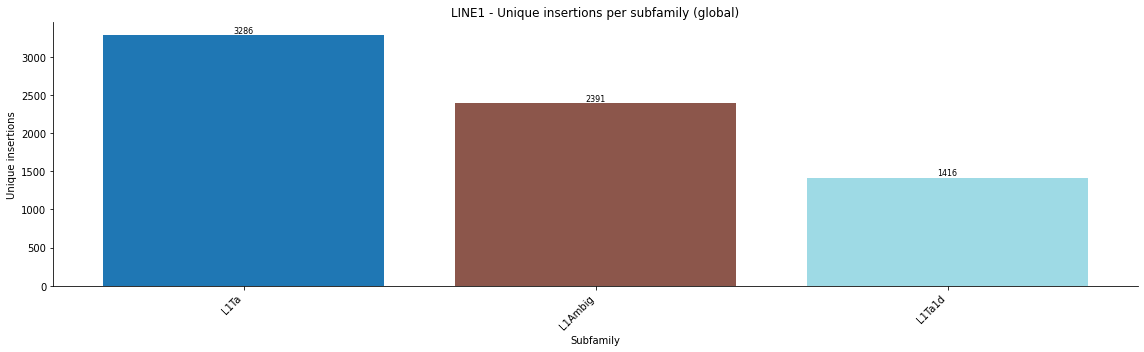

/tmp/ipykernel_352130/3405121477.py:56: UserWarning: FixedFormatter should only be used together with FixedLocator
  axes[i].set_xticklabels(sub["subfamily_plot"].astype(str), rotation=45, ha="right", fontsize=6)
/tmp/ipykernel_352130/3405121477.py:56: UserWarning: FixedFormatter should only be used together with FixedLocator
  axes[i].set_xticklabels(sub["subfamily_plot"].astype(str), rotation=45, ha="right", fontsize=6)
/tmp/ipykernel_352130/3405121477.py:56: UserWarning: FixedFormatter should only be used together with FixedLocator
  axes[i].set_xticklabels(sub["subfamily_plot"].astype(str), rotation=45, ha="right", fontsize=6)
/tmp/ipykernel_352130/3405121477.py:56: UserWarning: FixedFormatter should only be used together with FixedLocator
  axes[i].set_xticklabels(sub["subfamily_plot"].astype(str), rotation=45, ha="right", fontsize=6)
/tmp/ipykernel_352130/3405121477.py:56: UserWarning: FixedFormatter should only be used together with FixedLocator
  axes[i].set_xticklabels(sub["su

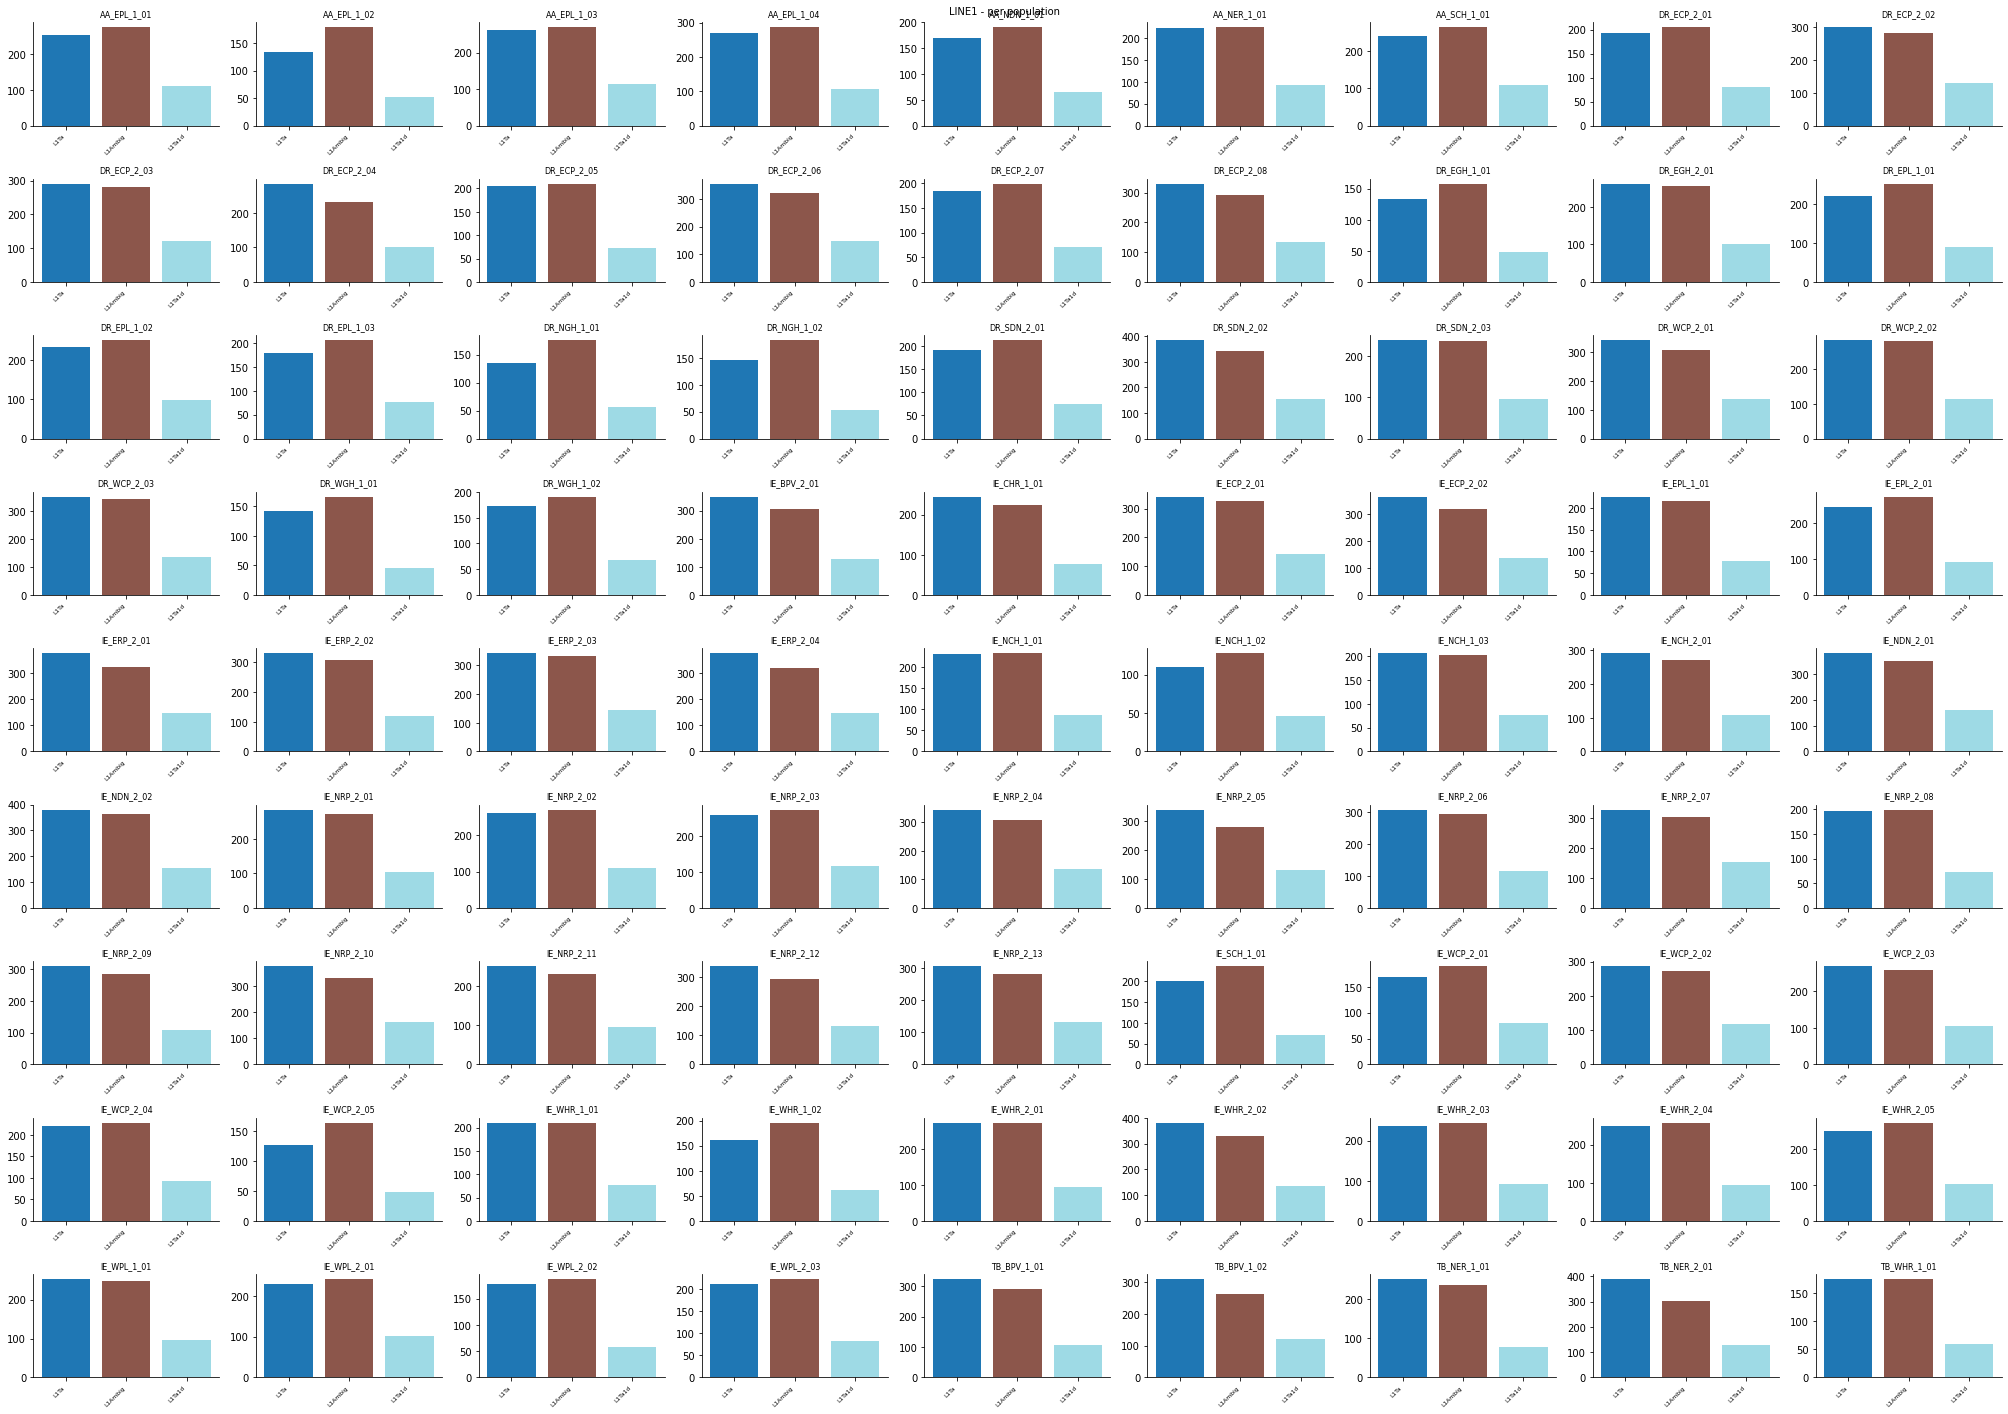

  Saved line1_per_pop.png


/tmp/ipykernel_352130/3405121477.py:56: UserWarning: FixedFormatter should only be used together with FixedLocator
  axes[i].set_xticklabels(sub["subfamily_plot"].astype(str), rotation=45, ha="right", fontsize=6)
/tmp/ipykernel_352130/3405121477.py:56: UserWarning: FixedFormatter should only be used together with FixedLocator
  axes[i].set_xticklabels(sub["subfamily_plot"].astype(str), rotation=45, ha="right", fontsize=6)
/tmp/ipykernel_352130/3405121477.py:56: UserWarning: FixedFormatter should only be used together with FixedLocator
  axes[i].set_xticklabels(sub["subfamily_plot"].astype(str), rotation=45, ha="right", fontsize=6)
/tmp/ipykernel_352130/3405121477.py:56: UserWarning: FixedFormatter should only be used together with FixedLocator
  axes[i].set_xticklabels(sub["subfamily_plot"].astype(str), rotation=45, ha="right", fontsize=6)
/tmp/ipykernel_352130/3405121477.py:56: UserWarning: FixedFormatter should only be used together with FixedLocator
  axes[i].set_xticklabels(sub["su

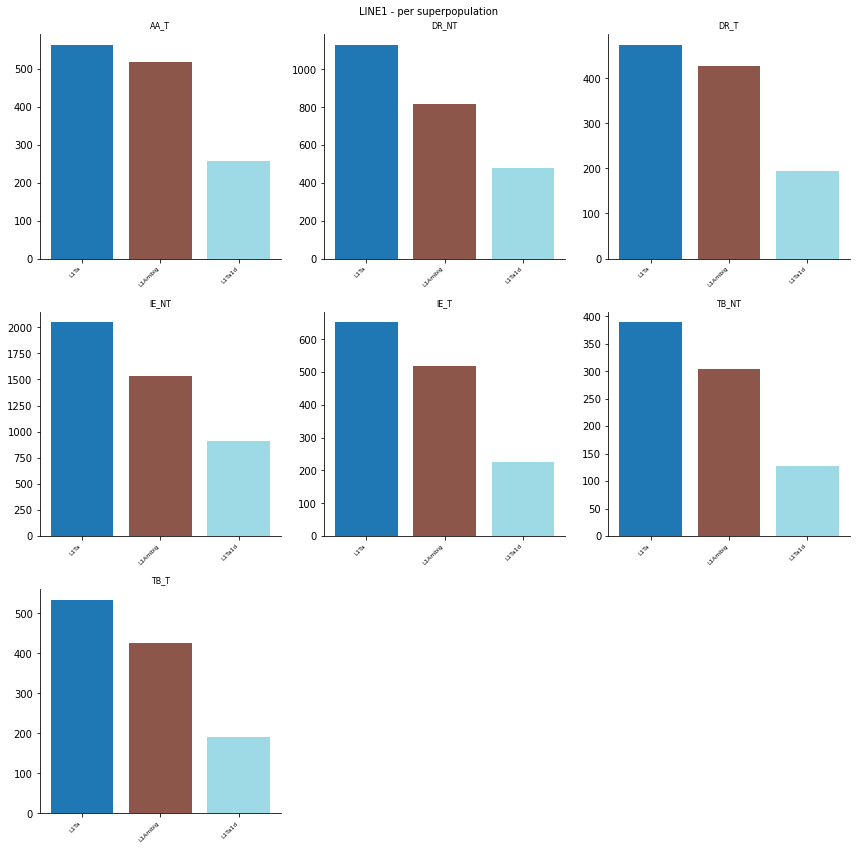

  Saved line1_per_superpop.png


In [10]:
l1_counts = build_counts(f"{OUTDIR}/LINE1_gt_raw.tsv", f"{OUTDIR}/LINE1_samples.txt", map_df, "LINE1")
make_plots(l1_counts, "LINE1", OUTDIR, top_n=20)